In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

In [2]:
df=pd.read_csv("C:/Users/User/Desktop/Sentiment Analysis/sentiment_dataset/Reviews.csv")

In [3]:
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [4]:
df.shape

(568454, 10)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.isnull().sum()

Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64

In [8]:
df["Score"].unique()

array([5, 1, 4, 2, 3])

In [9]:
df["Score"].value_counts()

Score
5    363122
4     80655
1     52268
3     42640
2     29769
Name: count, dtype: int64

Score is an integer (target variable).
Text and Summary are object (text) columns.
Time is stored as an integer Unix timestamp.
HelpfulnessNumerator and HelpfulnessDenominator are numerical features.

The dataset contains 568,454 reviews and 10 features. There are very few missing values, no duplicate records, and the target variable (Score) is imbalanced, with 5-star reviews occurring most frequently. The Text column appears to be the primary feature for sentiment prediction, while Summary may also be useful. Identifier columns such as Id, UserId, and ProfileName are unlikely to contribute to sentiment prediction.

# EDA

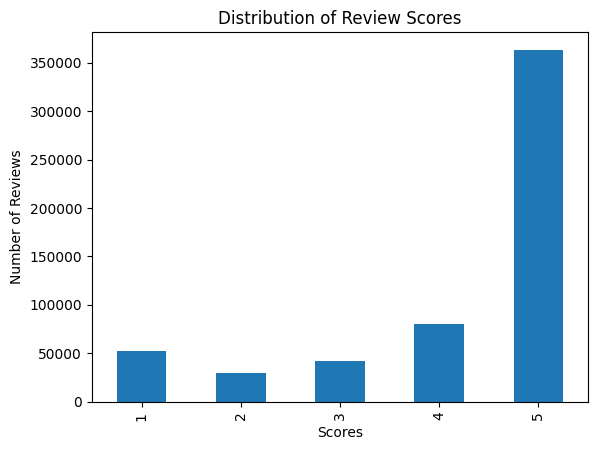

In [10]:
df["Score"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribution of Review Scores")
plt.xlabel("Scores")
plt.ylabel("Number of Reviews")
plt.show()


In [11]:
df["Review_Length"]=df["Text"].str.split().str.len()

In [12]:
df["Review_Length"].head()

0    48
1    31
2    94
3    41
4    27
Name: Review_Length, dtype: int64

In [13]:
df["Review_Length"].describe()

count    568454.000000
mean         80.264023
std          79.455384
min           3.000000
25%          33.000000
50%          56.000000
75%          98.000000
max        3432.000000
Name: Review_Length, dtype: float64

In [14]:
df.groupby("Score")["Review_Length"].mean()

Score
1    87.323697
2    90.040881
3    95.645755
4    91.393156
5    74.168167
Name: Review_Length, dtype: float64

<Axes: xlabel='Score'>

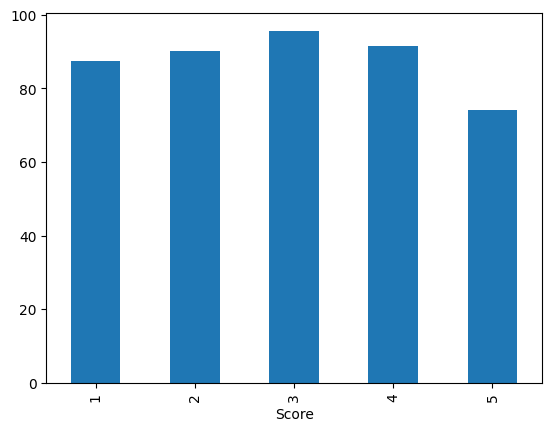

In [15]:
df.groupby("Score")["Review_Length"].mean().plot(kind="bar")

<Axes: ylabel='Frequency'>

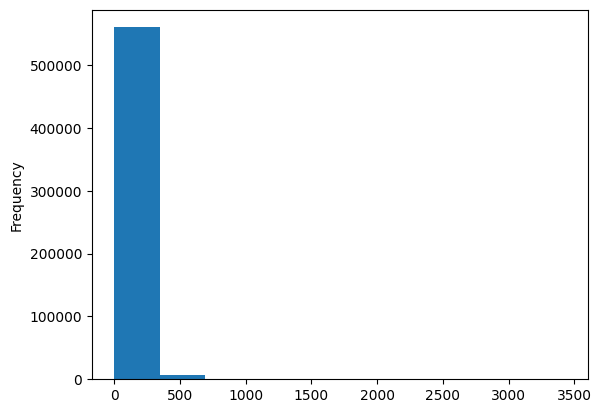

In [16]:
df["Review_Length"].plot(kind="hist")

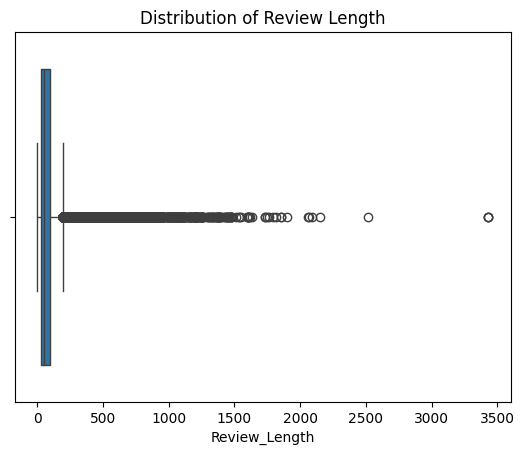

In [17]:
sns.boxplot(x=df["Review_Length"])
plt.title("Distribution of Review Length")
plt.show()

# Data Cleaning & Text Preprocessing

In [18]:
df[df["ProfileName"].isna()].head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,Review_Length
10616,10617,B002DHN956,A1LSYR30XW7CFT,NaN,1,2,5,1291680000,Awesome,This is 72 for the price of like 24 at the gro...,52
25509,25510,B000LKZB4Y,A36BVYD0NT7Z0F,NaN,0,0,5,1314576000,These are the best mints and no aspartame or BHT,I was so shocked to find out that almost all g...,89
38874,38875,B000AYDGZ2,A36BVYD0NT7Z0F,NaN,2,3,1,1278374400,doesn't anyone care that they are putting BHT ...,I called Kellogg's to see why Special K red be...,72
47923,47924,B004SRH2B6,A2DEHJJIEAPPBF,NaN,0,0,5,1338940800,Great taste,Enjoy drinking this brand. Tastes as good as ...,24
49800,49801,B000CRHQN0,A2LYFY32LXQDON,NaN,0,0,2,1282608000,They were melted and the chocolate had turned ...,We love these bars but i won't order them ship...,29


In [19]:
df[df["Summary"].isna()]

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,Review_Length
33958,33959,B00412W76S,A3TJPSWY2HE4BS,"S. Layton ""homeschool blogger""",1,24,2,1173312000,NaN,I only used two maybe three tea bags and got p...,29
40548,40549,B00020HHRW,A3TJPSWY2HE4BS,"S. Layton ""homeschool blogger""",1,24,2,1173312000,NaN,I only used two maybe three tea bags and got p...,29
101106,101107,B0014B0HWK,A3TJPSWY2HE4BS,"S. Layton ""homeschool blogger""",1,24,2,1173312000,NaN,I only used two maybe three tea bags and got p...,29
102979,102980,B000FVDWU4,A3TJPSWY2HE4BS,"S. Layton ""homeschool blogger""",1,24,2,1173312000,NaN,I only used two maybe three tea bags and got p...,29
117515,117516,B0016B7Z32,A3TJPSWY2HE4BS,"S. Layton ""homeschool blogger""",1,24,2,1173312000,NaN,I only used two maybe three tea bags and got p...,29
155712,155713,B0009VO58S,A3TJPSWY2HE4BS,"S. Layton ""homeschool blogger""",1,24,2,1173312000,NaN,I only used two maybe three tea bags and got p...,29
178290,178291,B00073IVAQ,A3TJPSWY2HE4BS,"S. Layton ""homeschool blogger""",1,24,2,1173312000,NaN,I only used two maybe three tea bags and got p...,29
198474,198475,B000FVBYCW,A3TJPSWY2HE4BS,"S. Layton ""homeschool blogger""",1,24,2,1173312000,NaN,I only used two maybe three tea bags and got p...,29
212691,212692,B00020HHAO,A3TJPSWY2HE4BS,"S. Layton ""homeschool blogger""",1,24,2,1173312000,NaN,I only used two maybe three tea bags and got p...,29
237565,237566,B000ELGPAO,A15AMT9T9A1309,Film-Friend,1,1,3,1328572800,NaN,This is a cool system only problem is that the...,33


Missing Values & Column Removal:
The dataset contained 26 missing values in ProfileName and 27 missing values in Summary. After investigating these records, no data-quality issue requiring removal of the corresponding rows was identified. ProfileName was removed because it does not provide useful information for sentiment prediction. Summary was also removed because the complete Text column provides richer information and will be used as the primary text feature. Therefore, the missing values in these columns were eliminated by dropping the columns rather than removing the associated reviews.

In [20]:
df.drop(columns=["ProfileName","Summary"],inplace=True)

In [21]:
df.shape

(568454, 9)

In [22]:
sentiment_mapping={ 1:'Negative',2:'Negative',3:'Neutral',4:'Positive',5:'Positive'}
df["Sentiment"]=df["Score"].map(sentiment_mapping)

In [23]:
df[["Sentiment","Score"]].head()

,Sentiment,Score
0,Positive,5
1,Negative,1
2,Positive,4
3,Negative,2
4,Positive,5


In [24]:
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [25]:
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [26]:
def preprocessing(text):
    text=text.lower()
    for ch in string.punctuation:
        text=text.replace(ch,"")
    words=text.split()
    stemmed_words=[]
    stop_words=set(stopwords.words("english"))
    negations={"no","not","never","nor"}
    custom_words=stop_words-negations
    for word in words:
        if word not in custom_words:
            stemmed_words.append(word)
    Lemmatized_words=[]
    lm=WordNetLemmatizer()
    for word in stemmed_words:
        Lemmatized_words.append(lm.lemmatize(word))
    return " ".join(Lemmatized_words)

In [27]:
test_texts = [
    "This product is NOT good!",
    "I absolutely loved this product.",
    "I never liked this product.",
    "The packaging was terrible, but the taste was good.",
    "THIS PRODUCT IS AMAZING!!!"
]

In [28]:
for text in test_texts:
    print("Original:", text)
    print("Processed:", preprocessing(text))
    print()

Original: This product is NOT good!
Processed: product not good

Original: I absolutely loved this product.
Processed: absolutely loved product

Original: I never liked this product.
Processed: never liked product

Original: The packaging was terrible, but the taste was good.
Processed: packaging terrible taste good

Original: THIS PRODUCT IS AMAZING!!!
Processed: product amazing



In [29]:
df["Text"]=df["Text"].apply(preprocessing)

In [30]:
df[["Text","Sentiment"]].head(10)

,Text,Sentiment
0,bought several vitality canned dog food produc...,Positive
1,product arrived labeled jumbo salted peanutsth...,Negative
2,confection around century light pillowy citrus...,Positive
3,looking secret ingredient robitussin believe f...,Negative
4,great taffy great price wide assortment yummy ...,Positive
5,got wild hair taffy ordered five pound bag taf...,Positive
6,saltwater taffy great flavor soft chewy candy ...,Positive
7,taffy good soft chewy flavor amazing would def...,Positive
8,right im mostly sprouting cat eat grass love r...,Positive
9,healthy dog food good digestion also good smal...,Positive


In [31]:
(df["Text"].str.len()==0).sum()

np.int64(0)

# Vectorization

In [32]:
x=df["Text"]
y=df["Sentiment"]

In [33]:
from sklearn.model_selection import train_test_split

In [34]:
Xtrain,Xtest,Ytrain,Ytest=train_test_split(x,y,random_state=42,test_size=0.2,stratify=y)

In [35]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf=TfidfVectorizer()
Xtrain_tfidf=tfidf.fit_transform(Xtrain)
Xtest_tfidf=tfidf.transform(Xtest)

In [36]:
print(Xtrain_tfidf.shape)
print(Xtest_tfidf.shape)

(454763, 205009)
(113691, 205009)


In [37]:
type(Xtrain_tfidf)

scipy.sparse._csr.csr_matrix

In [38]:
len(tfidf.vocabulary_)

205009

In [39]:
tfidf.get_feature_names_out()[:20]

array(['00', '000', '0000', '000001', '00001', '000013', '00004br',
       '0000soo', '000100z', '0001br', '0004', '0008', '0009373', '000br',
       '001', '0010', '00100', '00127', '00128', '00129'], dtype=object)

# Model Training

In [40]:
# Logistic Regression

In [41]:
from sklearn.linear_model import LogisticRegression

In [42]:
model_1=LogisticRegression(random_state=42, max_iter=500)
model_1.fit(Xtrain_tfidf,Ytrain)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [43]:
y_pred=model_1.predict(Xtest_tfidf)

In [44]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [45]:
accuracy_1=accuracy_score(Ytest,y_pred)
print("Accuracy of Model 1:",accuracy_1)
print(confusion_matrix(Ytest,y_pred))
print(classification_report(Ytest,y_pred))

Accuracy of Model 1: 0.8805710214528855
[[11706   594  4107]
 [ 1751  2197  4580]
 [ 1765   781 86210]]
              precision    recall  f1-score   support

    Negative       0.77      0.71      0.74     16407
     Neutral       0.62      0.26      0.36      8528
    Positive       0.91      0.97      0.94     88756

    accuracy                           0.88    113691
   macro avg       0.76      0.65      0.68    113691
weighted avg       0.87      0.88      0.87    113691



In [46]:
# Multinomial Naive Bayes

In [47]:
from sklearn.naive_bayes import MultinomialNB

In [48]:
model_2=MultinomialNB()
model_2.fit(Xtrain_tfidf,Ytrain)
Ypred=model_2.predict(Xtest_tfidf)

In [49]:
accuracy_2=accuracy_score(Ytest,Ypred)
print("Accuracy of 2nd model:",accuracy_2)
print("Confusion Matrix:")
print(confusion_matrix(Ytest,Ypred))
print("Classification Report:")
print(classification_report(Ytest,Ypred))

Accuracy of 2nd model: 0.7915314316876446
Confusion Matrix:
[[ 1253     0 15154]
 [   26    20  8482]
 [   25    14 88717]]
Classification Report:
              precision    recall  f1-score   support

    Negative       0.96      0.08      0.14     16407
     Neutral       0.59      0.00      0.00      8528
    Positive       0.79      1.00      0.88     88756

    accuracy                           0.79    113691
   macro avg       0.78      0.36      0.34    113691
weighted avg       0.80      0.79      0.71    113691



In [50]:
# Linear Support Vector Machine

In [51]:
from sklearn.svm import LinearSVC
model_3=LinearSVC(random_state=42)
model_3.fit(Xtrain_tfidf,Ytrain)
Ypred_3=model_3.predict(Xtest_tfidf)

In [52]:
accuracy_3=accuracy_score(Ytest,Ypred_3)
print("Accuracy of 3rd model:",accuracy_3)
print("Confusion Matrix:")
print(confusion_matrix(Ytest,Ypred_3))
print("Classification Report:")
print(classification_report(Ytest,Ypred_3))

Accuracy of 3rd model: 0.8895515036370513
Confusion Matrix:
[[12247   487  3673]
 [ 1756  2553  4219]
 [ 1812   610 86334]]
Classification Report:
              precision    recall  f1-score   support

    Negative       0.77      0.75      0.76     16407
     Neutral       0.70      0.30      0.42      8528
    Positive       0.92      0.97      0.94     88756

    accuracy                           0.89    113691
   macro avg       0.80      0.67      0.71    113691
weighted avg       0.88      0.89      0.88    113691



In [53]:
# Hyperparameter Tuning

In [54]:
from sklearn.model_selection import GridSearchCV
svm = LinearSVC()
param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "class_weight": [None, "balanced"]
}
grid_svm = GridSearchCV(
    svm,
    param_grid,
    cv=3,
    scoring="f1_macro",
    n_jobs=-1
)
grid_svm.fit(Xtrain_tfidf, Ytrain)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LinearSVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'class_weight': [None, 'balanced']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold an

In [55]:
grid_svm.best_params_
grid_svm.best_score_

np.float64(0.7200354702904628)

In [56]:
best_svm = grid_svm.best_estimator_

Ypred_svm_tuned = best_svm.predict(Xtest_tfidf)

In [57]:
print("Acc:",accuracy_score(Ytest, Ypred_svm_tuned))
print(confusion_matrix(Ytest, Ypred_svm_tuned))
print(classification_report(Ytest, Ypred_svm_tuned))

Acc: 0.8782841209946258
[[12920  1518  1969]
 [ 1770  4345  2413]
 [ 2947  3221 82588]]
              precision    recall  f1-score   support

    Negative       0.73      0.79      0.76     16407
     Neutral       0.48      0.51      0.49      8528
    Positive       0.95      0.93      0.94     88756

    accuracy                           0.88    113691
   macro avg       0.72      0.74      0.73    113691
weighted avg       0.88      0.88      0.88    113691



In [58]:
grid_svm.best_params_

{'C': 1, 'class_weight': 'balanced'}

In [59]:
lr = LogisticRegression(
    max_iter=500,
    random_state=42
)
param_grid_lr = {
    "C": [0.01, 0.1, 1, 10],
    "class_weight": [None, "balanced"]
}
grid_lr = GridSearchCV(
    lr,
    param_grid_lr,
    cv=3,
    scoring="f1_macro",
    n_jobs=-1
)
grid_lr.fit(Xtrain_tfidf, Ytrain)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'class_weight': [None, 'balanced']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed

In [60]:
grid_lr.best_params_
grid_lr.best_score_

np.float64(0.7099429221625398)

In [61]:
best_lr = grid_lr.best_estimator_

Ypred_lr = best_lr.predict(Xtest_tfidf)

In [62]:
print("Acc:",accuracy_score(Ytest, Ypred_lr))
print(confusion_matrix(Ytest, Ypred_lr))
print(classification_report(Ytest, Ypred_lr))

Acc: 0.8892260601102989
[[12235   839  3333]
 [ 1642  3171  3715]
 [ 1865  1200 85691]]
              precision    recall  f1-score   support

    Negative       0.78      0.75      0.76     16407
     Neutral       0.61      0.37      0.46      8528
    Positive       0.92      0.97      0.94     88756

    accuracy                           0.89    113691
   macro avg       0.77      0.69      0.72    113691
weighted avg       0.88      0.89      0.88    113691



In [64]:
# Saving Model

In [63]:
import joblib
joblib.dump(best_svm, "sentiment_svm_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']